#Malware Detection

##Import Required Library



In [3]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as ssb

## Import Data

In [4]:
#import data
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DynamicMalwareMatrix2.csv")
data.head()

,labels,00,0000,0000000,000000000046,00021401,00c04fc295ee,01,0156250,02,...,windowsruntime,winevt,wmiprvse,working,wow6432node,write,writefile,xaml,xls,zip
0,1,11,0,5,0,0,0,1,6,0,...,0,0,0,36,0,0,0,0,0,0
1,1,0,0,1,0,0,0,0,0,0,...,0,0,0,19,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,3,0,...,0,0,0,8,0,0,0,0,0,0
3,1,52,0,2,0,0,0,2,0,6,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data.shape

(34371, 501)

##Data Processing

In [6]:
#Data Processing
# dividing data input and output x, y for input and outputs respectively
X = data.drop("labels",axis = 1)
y = data["labels"]

In [7]:
# split data for training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,random_state =42, test_size=0.3)

In [8]:
scores =[]

##Modelling


### Decision Tree Classifier

In [9]:
# modelling from sklearn lib using Desision tree algo
from sklearn.tree import DecisionTreeClassifier
Treemodel = DecisionTreeClassifier(random_state=42)

In [10]:
# model training
tree = Treemodel.fit(X_train, y_train)

In [11]:
# predicting values
y_pred = tree.predict(X_test)
test_compare = pd.DataFrame({'y_test': y_test,'y_pred': y_pred})
test_compare.head(10)
# the data set is label as 1 for goodware and -1 for malware

,y_test,y_pred
32669,-1,-1
8480,1,1
27209,-1,-1
34013,-1,-1
15272,1,1
4990,1,1
8139,1,1
12536,1,1
24437,-1,-1
28379,-1,-1


#### Evaluating Results of Decision Tree Model

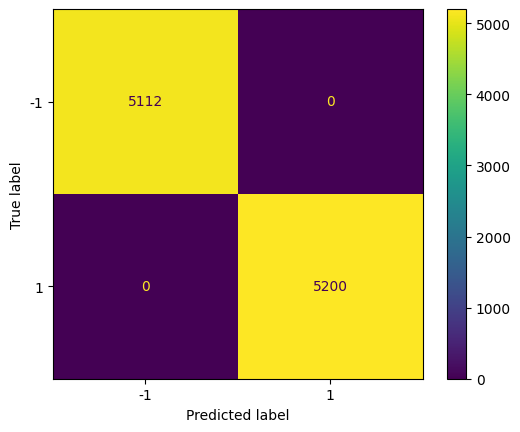

In [12]:
# Evaluating Results of Decision Tree Model
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(tree, X_test, y_pred)

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
print('Classification Report')
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00      5104
           1       1.00      1.00      1.00      5208

    accuracy                           1.00     10312
   macro avg       1.00      1.00      1.00     10312
weighted avg       1.00      1.00      1.00     10312



In [14]:
print('Score', tree.score(X_test, y_test))
scores.append(tree.score(X_test, y_test))

Score 0.997478665632273


### Random Forest Classifier

In [15]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
forestmodel = RandomForestClassifier(random_state=42)


In [16]:
# model fit
forest = forestmodel.fit(X_train, y_train)

In [17]:
# predicting values
y_pred = forest.predict(X_test)
test_compare = pd.DataFrame({'y_test': y_test,'y_pred': y_pred})
test_compare.head(10)

,y_test,y_pred
32669,-1,-1
8480,1,1
27209,-1,-1
34013,-1,-1
15272,1,1
4990,1,1
8139,1,1
12536,1,1
24437,-1,-1
28379,-1,-1


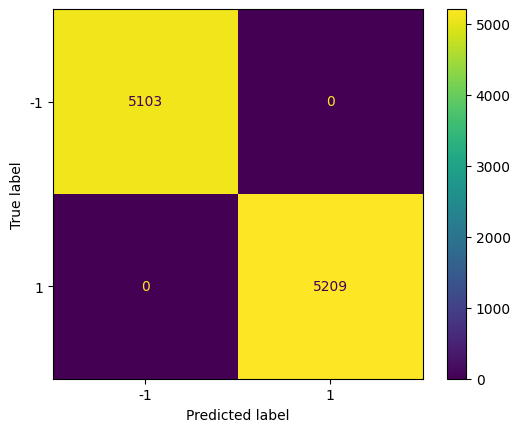

In [18]:
# Evaluating Results of Random Forest Classifier
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(forest, X_test, y_pred)

In [19]:
# classification report
from sklearn.metrics import confusion_matrix, classification_report
print('Classification Report')
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00      5104
           1       1.00      1.00      1.00      5208

    accuracy                           1.00     10312
   macro avg       1.00      1.00      1.00     10312
weighted avg       1.00      1.00      1.00     10312



In [20]:
# score
print('Score', forest.score(X_test, y_test))
scores.append(forest.score(X_test, y_test))

Score 0.9995151280062063


### logistic regression

In [21]:
# logistic regression
# standard scaling
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [22]:
#import model
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=500)

In [23]:
log = logmodel.fit(X_train, y_train)

In [24]:
#performing predictions on test set
y_pred = log.predict(X_test)
test_compare = pd.DataFrame({'y_test': y_test,'y_pred': y_pred})
test_compare.head(10)

,y_test,y_pred
32669,-1,-1
8480,1,1
27209,-1,-1
34013,-1,-1
15272,1,1
4990,1,1
8139,1,1
12536,1,1
24437,-1,-1
28379,-1,-1


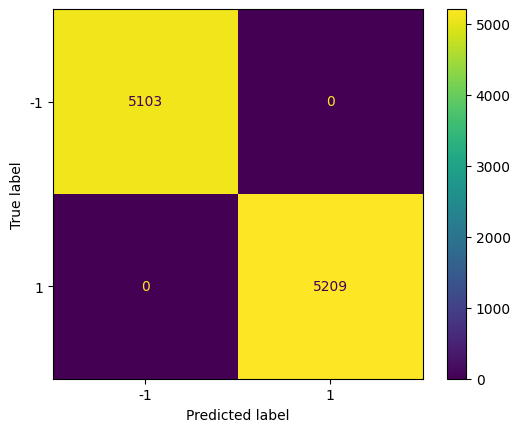

In [25]:
#evaluvation on the logistic regression model
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(log, X_test, y_pred)

In [26]:
print('Score', log.score(X_test, y_test))
scores.append(log.score(X_test, y_test))

Score 0.9997090768037238


## Comparision of Models

In [27]:
# Comparisions of all models score percentage
print("Comparisions of all models score percentage")
print("Decision Tree Classifier", round(scores[0]*100,5))
print("Random Forest Classifier", round(scores[1]*100,5))
print("Logistic Regression", round(scores[2]*100,5))

Comparisions of all models score percentage
Decision Tree Classifier 99.74787
Random Forest Classifier 99.95151
Logistic Regression 99.97091
